# Locating an earthquake with matched-field processing

Matched-field processing (MFP) extends plane-wave beamforming to three
dimensions by replacing the plane-wave steering vector with a
*replica* — a predicted wavefield for a point source at each candidate
grid location. This allows simultaneous estimation of back-azimuth,
horizontal range, and **depth**.

This example locates the Mb 4.4 earthquake that occurred in the Aegean Sea
on 5 October 2020 (39.88°N, 23.35°E, 10 km depth), using the same regional
network as the back-projection example. We demonstrate:

1. Building a constant-velocity model over the network area,
2. Computing per-station travel-time grids with
   `covseisnet.travel_times.TravelTimes`,
3. Validating the Bartlett and MVDR processors on a synthetic covariance
   injected at the known epicentre,
4. Applying the processors to the real earthquake covariance and comparing
   the recovered location with the catalogue position.


In [32]:
from cartopy.crs import PlateCarree
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

import covseisnet as csn
from covseisnet.matchedfield import MatchedFieldProcessing
import covseisnet.synthetic as syn

## Load seismograms and station coordinates

We load the Aegean Sea example data, download the station inventory from the
National Observatory of Athens (NOA), and pre-process the waveforms exactly
as in the back-projection example: merge, detrend, high-pass filter, and
synchronise. We also plot the station map with the known catalogue epicentre,
and capture the map extent for use in the velocity model grid.


In [40]:
data = np.load("covariances.npz", allow_pickle=True)
data["covariances"].stats

AttributeError: 'numpy.ndarray' object has no attribute 'stats'

## Velocity model and travel times

We build a constant-velocity model at 3.5 km/s (S-wave dominated) over the
geographic extent returned by the station map, extended from −3 to 20 km
depth to encompass both shallow and crustal sources. For each station we
compute the travel time from every grid point to that receiver.


In [ ]:
# Append depth range to the horizontal extent from the map
extent_with_depth = -138.5, -139, 35.2, 35.5, -5, 60

velocity_model = csn.velocity.VelocityModel(
    extent=extent_with_depth, shape=(40, 40, 20), velocity=3.5
)

# Per-station travel-time grids
travel_times = {
    tr.stats.station: csn.calculate_travel_times(
        velocity_model, stats=tr.stats
    )
    for tr in stream
}
print(f"TravelTimes grid shape: {next(iter(travel_times.values())).shape}")

# Station coordinates for plotting
receiver_coords = None

NameError: name 'extent' is not defined

/Users/seydoux/GitHub/covseisnet/covseisnet/plot.py:634: UserWarning: The following kwargs were not used by contour: 'receiver_coords', 'source_location'
  mappable = ax["xy"].contourf(
/Users/seydoux/GitHub/covseisnet/covseisnet/plot.py:637: UserWarning: The following kwargs were not used by contour: 'receiver_coords', 'source_location'
  ax["xz"].contourf(
/Users/seydoux/GitHub/covseisnet/covseisnet/plot.py:640: UserWarning: The following kwargs were not used by contour: 'receiver_coords', 'source_location'
  ax["zy"].contourf(


(<Figure size 750x750 with 4 Axes>,
 {'xy': <Axes: label='xy', ylabel='Latitude (º)'>,
  'zy': <Axes: label='zy', xlabel='Depth (km)'>,
  'xz': <Axes: label='xz', xlabel='Longitude (º)', ylabel='Depth (km)'>,
  'cb': <Axes: label='cb'>})

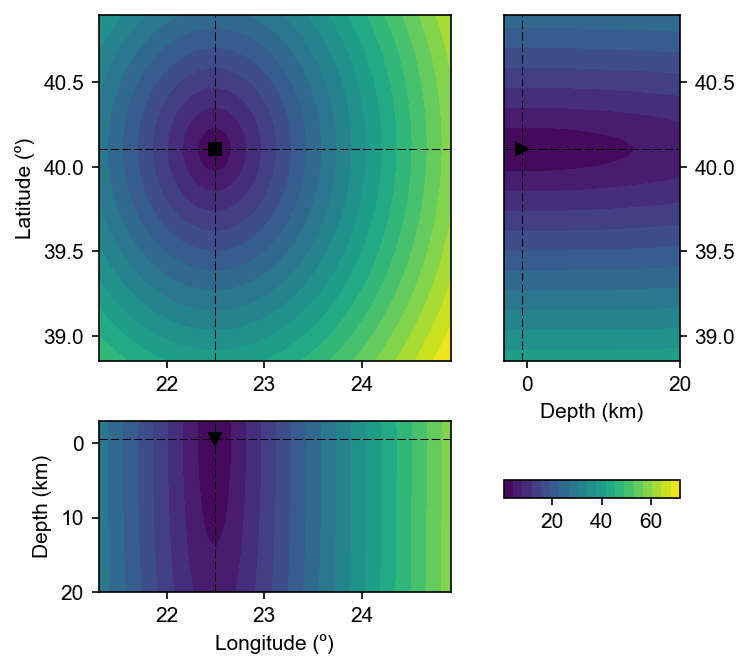

In [111]:
csn.plot.grid3d(
    travel_times["LIT"],
    receiver_coords=receiver_coords,
    source_location=source_location,
)

In [112]:
(travel_times["LIT"].lon[1] - travel_times["LIT"].lon[0]) * 111

np.float64(10.260147602936375)

## Gridless localization via phase-stacking

When the dominant wavelength $\lambda = v/f$ is shorter than the grid
spacing the standard Bartlett map is aliased: its maximum may land on an
arbitrary grating lobe rather than the true source.

The **phase-stacking** approach sidesteps the grid limit without rebuilding
any travel-time grids.  For each of $N$ trials an independent random delay

$$\delta t_j \sim \mathcal{U}(0,\, dt_{\max})$$

is drawn for every station $j$ and absorbed into the covariance phase:

$$\tilde{C}_{jk} = C_{jk}\,e^{\,2\pi i f(\delta t_j - \delta t_k)}$$

This is algebraically identical to evaluating Bartlett with travel times
$t_j(\mathbf{r}) + \delta t_j$, i.e. it shifts the effective search point
by a random sub-cell offset in delay space.  The element-wise maximum over
all trials recovers a near-continuous scan at the cost of $N$ matrix–vector
products on the **same** steering matrix — no new `TravelTimes` objects are
needed.

We also retain `locate_optimize` (differential evolution) as a fast
single-point cross-check.


wavelength: 17.50 km
grid spacing: 10.26 km
Minimum travel-time sampling interval: 2.93 s
29


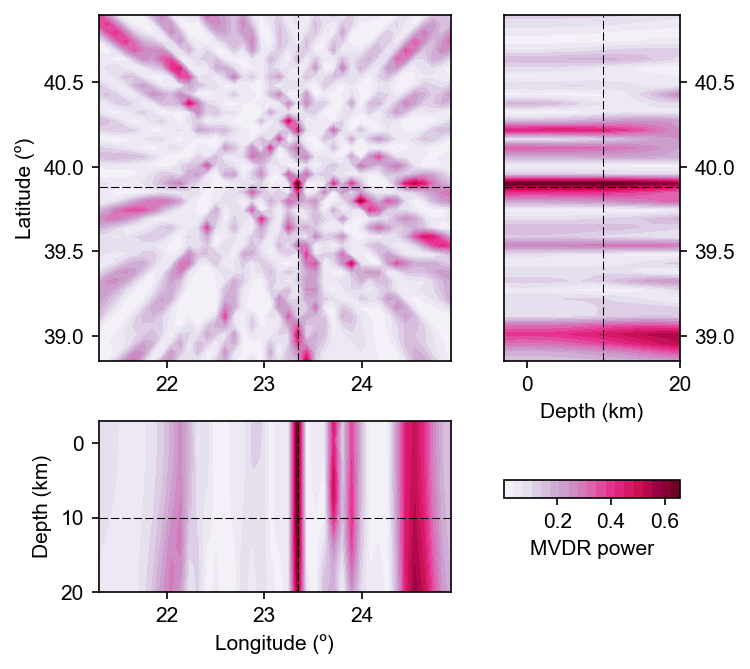

In [201]:
source = source_location
frequency = 0.2
slowness = 1 / 3.5

wavelength = 1 / (frequency * slowness)
print(f"wavelength: {wavelength:.2f} km")
grid_spacing = (travel_times["LIT"].lon[1] - travel_times["LIT"].lon[0]) * 111
print(f"grid spacing: {grid_spacing:.2f} km")
dt_min = grid_spacing * slowness
print(f"Minimum travel-time sampling interval: {dt_min:.2f} s")

cov_hf = syn.spherical_wave_covariance(stats, frequency, slowness, source)
cov_hf /= np.abs(cov_hf)
mfps = []
for i, rescale_time in enumerate(np.linspace(-dt_min, dt_min, 50)):
    travel_times_rescale = {
        station: tt + rescale_time for station, tt in travel_times.items()
    }
    if i == 0:
        mfp = MatchedFieldProcessing(travel_times_rescale)
        mfp.compute_bartlett(cov_hf, frequency)
    else:
        mfp = MatchedFieldProcessing(travel_times_rescale)
        mfp.compute_bartlett(cov_hf, frequency)
    mfps.append(mfp)

beam_max = np.argmax([m.max() for m in mfps])
print(beam_max)

# mfp *= 0
# mfp += np.max(mfps, axis=0)
mfp = mfps[10]
lon_grid, lat_grid, dep_grid = mfp.maximum_coordinates()
# # --- Grid-based Bartlett: expected to fail at this frequency ---
# mfp_hf = MatchedFieldProcessing(travel_times)
# mfp_hf.compute_bartlett(cov_hf, frequency)
# lon_grid, lat_grid, dep_grid = mfp_hf.maximum_coordinates()

fig, ax = csn.plot.grid3d(
    mfp,
    profile_coordinates=source,
    # receiver_coordinates=receiver_coords,
    cmap="PuRd",
    label="MVDR power",
)

In [ ]:
# --- Gridless: differential evolution in continuous (lon, lat, depth) space ---
lon_opt, lat_opt, dep_opt = mfp_hf.locate_optimize(cov_hf, frequency, seed=42)

print(
    f"True source    : lon={source[0]:.4f}° lat={source[1]:.4f}° depth={source[2]:.2f} km"
)
print(
    f"Grid maximum   : lon={lon_grid:.4f}° lat={lat_grid:.4f}° depth={dep_grid:.2f} km"
)
print(
    f"DE optimizer   : lon={lon_opt:.4f}° lat={lat_opt:.4f}° depth={dep_opt:.2f} km"
)

In [122]:
# dt_max: upper bound of random station delays.
# Setting it to the one-way travel time across one grid cell ensures the
# dithering covers a full sub-cell offset in phase space.
grid_spacing_km = (
    travel_times["LIT"].lon[1] - travel_times["LIT"].lon[0]
) * 111.0
dt_max = grid_spacing_km / 3.5  # [s] — one cell at 3.5 km/s
print(f"Grid spacing: {grid_spacing_km:.1f} km  →  dt_max = {dt_max:.2f} s")

mfp_stacked = MatchedFieldProcessing(travel_times)
mfp_stacked.compute_bartlett_phase_stacking(
    cov_hf, frequency, n_perturbations=500, dt_max=dt_max, seed=0
)
lon_stk, lat_stk, dep_stk = mfp_stacked.maximum_coordinates()

print(
    f"True source    : lon={source[0]:.4f}° lat={source[1]:.4f}° depth={source[2]:.2f} km"
)
print(
    f"Grid maximum   : lon={lon_grid:.4f}° lat={lat_grid:.4f}° depth={dep_grid:.2f} km"
)
print(
    f"Phase stacking : lon={lon_stk:.4f}° lat={lat_stk:.4f}° depth={dep_stk:.2f} km"
)
print(
    f"DE optimizer   : lon={lon_opt:.4f}° lat={lat_opt:.4f}° depth={dep_opt:.2f} km"
)

Grid spacing: 10.3 km  →  dt_max = 2.93 s
True source    : lon=23.3465° lat=39.8812° depth=10.00 km
Grid maximum   : lon=23.3369° lat=39.9025° depth=7.89 km
Phase stacking : lon=23.3369° lat=39.9025° depth=0.63 km
DE optimizer   : lon=23.3465° lat=39.8812° depth=10.00 km


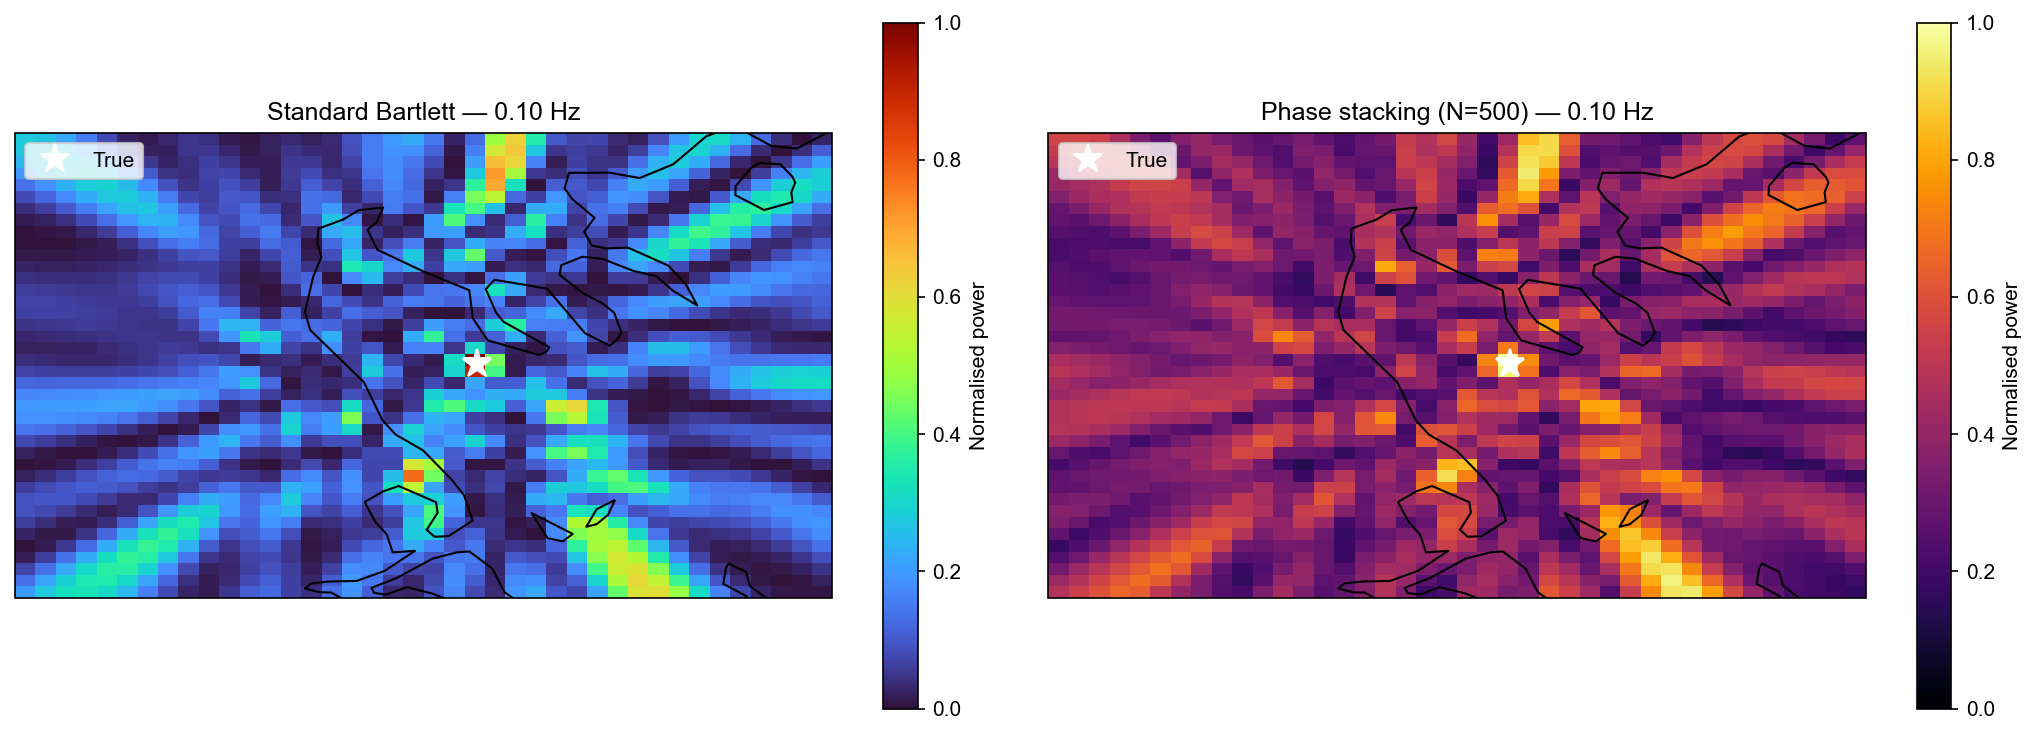

In [123]:
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": PlateCarree()}
)

for ax, grid, title, cmap in zip(
    axes,
    [mfp_hf, mfp_stacked],
    [
        f"Standard Bartlett — {frequency:.2f} Hz",
        f"Phase stacking (N=500) — {frequency:.2f} Hz",
    ],
    ["turbo", "inferno"],
):
    lons, lats, _ = grid.mesh
    sl = grid[:, :, 0]  # surface slice
    pcm = ax.pcolormesh(
        lons[:, :, 0],
        lats[:, :, 0],
        sl / np.nanmax(sl),
        cmap=cmap,
        vmin=0,
        vmax=1,
        transform=PlateCarree(),
    )
    ax.plot(
        *source[:2], "w*", markersize=14, transform=PlateCarree(), label="True"
    )
    ax.coastlines(resolution="50m")
    ax.set_title(title)
    plt.colorbar(pcm, ax=ax, label="Normalised power")
    ax.legend(loc="upper left")

fig.tight_layout()

## Grating-lobe suppression via delay-domain tapering

Grating lobes in the Bartlett map arise from station pairs with large
differential travel times $\tau_{jk} = t_j - t_k$: their cross-spectral
entries $C_{jk} e^{2\pi i f \tau_{jk}}$ wrap in phase whenever
$f |\tau_{jk}| > 1$, producing constructive interference at spurious locations.

The remedy is to **taper the covariance in the delay domain** — multiply each
entry $C_{jk}$ by a smooth window evaluated at $\tau_{jk}$:

$$\tilde{C}_{jk} = C_{jk} \cdot w\!\left(\frac{\tau_{jk}}{\sigma_\tau}\right)$$

This is the cross-spectral dual of time-domain smoothing of the
cross-correlation function.  Pairs whose delay exceeds $\sigma_\tau$ are
down-weighted, which collapses the lobes without any randomness, frequency
loop, or extra grid construction.  The resolution trades off against
$\sigma_\tau$: a larger window preserves long-baseline coherence (sharper
main lobe, more lobes); a smaller window suppresses lobes at the cost of
spatial blurring.

A natural choice for $\sigma_\tau$ is the one-way travel time across one
grid cell: $\sigma_\tau = \Delta x / v$.


In [197]:
source = source_location
f_centre = 2.0  # Hz — well above grid-spacing limit
slowness = 1 / 3.5

# sigma_tau = travel time across one grid cell
grid_spacing_km = (
    travel_times["LIT"].lon[1] - travel_times["LIT"].lon[0]
) * 111.0
sigma_tau = grid_spacing_km / 3.5
print(f"Grid spacing : {grid_spacing_km:.1f} km  →  σ_τ = {sigma_tau:.2f} s")

cov_hf = syn.spherical_wave_covariance(stats, f_centre, slowness, source)
cov_hf /= np.abs(cov_hf)

# Standard Bartlett (reference — grating lobes expected)
mfp_single = MatchedFieldProcessing(travel_times)
mfp_single.compute_bartlett(cov_hf, f_centre)
lon_sg, lat_sg, dep_sg = mfp_single.maximum_coordinates()

# Delay-tapered Bartlett — Gaussian window
mfp_tapered_g = MatchedFieldProcessing(travel_times)
mfp_tapered_g.compute_bartlett_delay_taper(
    cov_hf, f_centre, sigma_tau=sigma_tau, taper="gaussian"
)
lon_tg, lat_tg, dep_tg = mfp_tapered_g.maximum_coordinates()

# Delay-tapered Bartlett — Hann window
mfp_tapered_h = MatchedFieldProcessing(travel_times)
mfp_tapered_h.compute_bartlett_delay_taper(
    cov_hf, f_centre, sigma_tau=sigma_tau, taper="hann"
)
lon_th, lat_th, dep_th = mfp_tapered_h.maximum_coordinates()

print(
    f"\nTrue source          : lon={source[0]:.4f}° lat={source[1]:.4f}° depth={source[2]:.2f} km"
)
print(
    f"Standard Bartlett    : lon={lon_sg:.4f}° lat={lat_sg:.4f}° depth={dep_sg:.2f} km"
)
print(
    f"Tapered (Gaussian)   : lon={lon_tg:.4f}° lat={lat_tg:.4f}° depth={dep_tg:.2f} km"
)
print(
    f"Tapered (Hann)       : lon={lon_th:.4f}° lat={lat_th:.4f}° depth={dep_th:.2f} km"
)

Grid spacing : 10.3 km  →  σ_τ = 2.93 s

True source          : lon=23.3465° lat=39.8812° depth=10.00 km
Standard Bartlett    : lon=24.3537° lat=38.9029° depth=20.00 km
Tapered (Gaussian)   : lon=24.3537° lat=38.9029° depth=20.00 km
Tapered (Hann)       : lon=23.6142° lat=40.1129° depth=-3.00 km


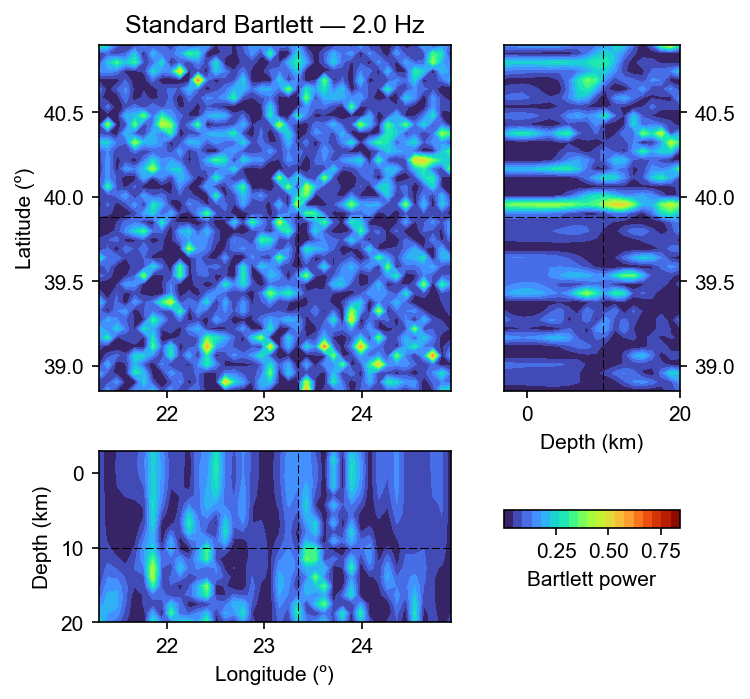

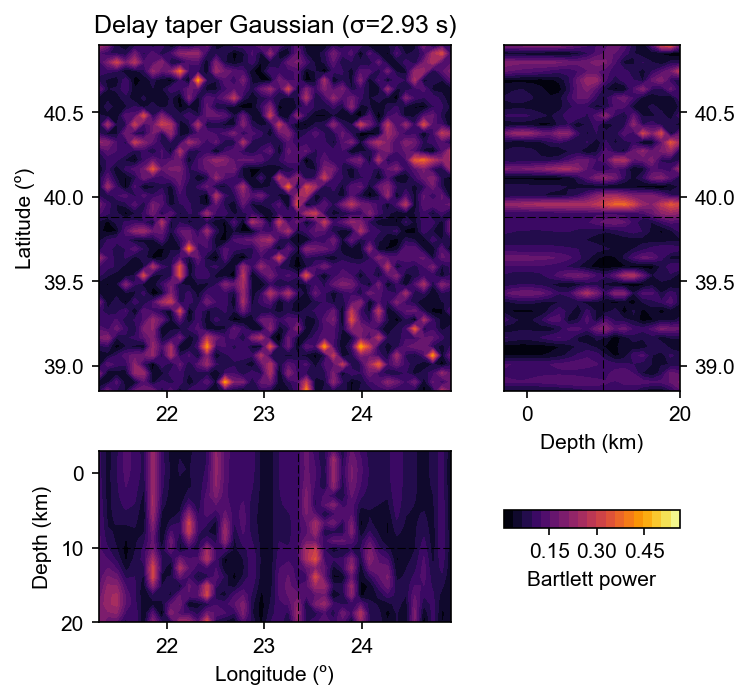

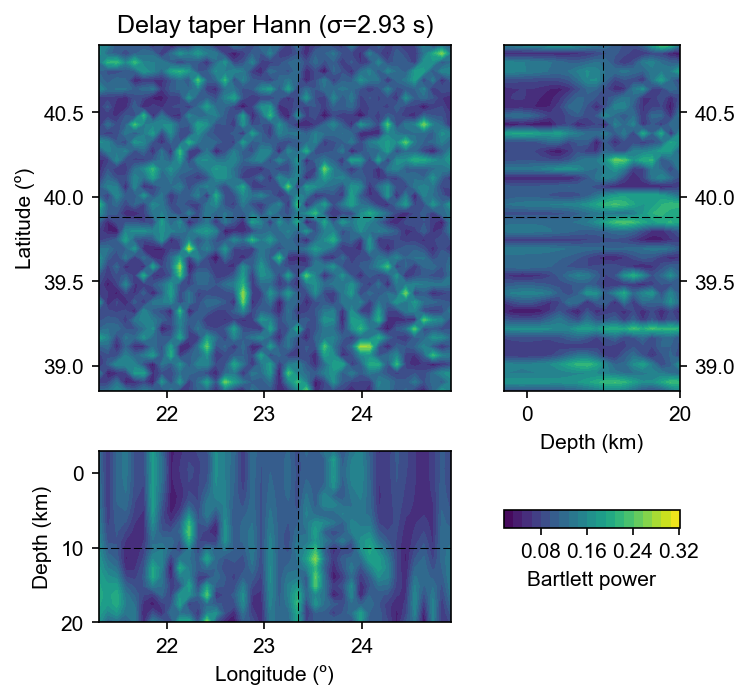

In [198]:
for grid, title, cmap in [
    (mfp_single, f"Standard Bartlett — {f_centre:.1f} Hz", "turbo"),
    (mfp_tapered_g, f"Delay taper Gaussian (σ={sigma_tau:.2f} s)", "inferno"),
    (mfp_tapered_h, f"Delay taper Hann (σ={sigma_tau:.2f} s)", "viridis"),
]:
    fig, ax = csn.plot.grid3d(
        grid,
        profile_coordinates=source,
        cmap=cmap,
        label="Bartlett power",
    )
    ax["xy"].set_title(title)

## Deterministic sub-wavelength localization via iterative grid refinement

The delay-domain taper and frequency stacking both act on a fixed grid, so
their maximum resolution is bounded by the grid spacing regardless of
frequency.  The root cause is simple: if the true source falls between grid
nodes, no amount of sidelobe suppression can move the map maximum to the
right location.

The correct deterministic remedy is **iterative grid refinement**:

1. Run Bartlett at the coarse level → approximate location (works fine
   because at low frequency the main lobe is wider than the grid spacing).
2. Build a new grid centred on that estimate, with spacing shrunk by a
   factor $z$ (e.g. $z = 5$).
3. Run Bartlett on the fine grid → better estimate.
4. Repeat until the grid spacing is smaller than the desired accuracy.

After $n$ iterations the effective spacing is $\Delta x / z^n$.  With
$z = 5$ and $n = 4$ the spacing shrinks by $5^4 = 625\times$ — from
~12 km down to ~20 m in four steps.  Each step costs one Bartlett
evaluation on the same-size local grid; the total computation is
dominated by the final (finest) level.


In [199]:
source = source_location
frequency = 2.0  # Hz — wavelength ~1.75 km, well below ~12 km grid spacing
slowness = 1 / 3.5

cov_hf = syn.spherical_wave_covariance(stats, frequency, slowness, source)
cov_hf /= np.abs(cov_hf)

# Coarse Bartlett (reference — grid-limited)
mfp_coarse = MatchedFieldProcessing(travel_times)
mfp_coarse.compute_bartlett(cov_hf, frequency)
lon_c, lat_c, dep_c = mfp_coarse.maximum_coordinates()

# Iterative refinement: 4 zoom levels at factor 5 → spacing shrinks 625×
mfp_fine = mfp_coarse.locate_refine(
    cov_hf, frequency, n_iter=4, zoom_factor=5, shape=(20, 20, 10)
)
lon_f, lat_f, dep_f = mfp_fine.maximum_coordinates()

grid_spacing_km = (
    travel_times["LIT"].lon[1] - travel_times["LIT"].lon[0]
) * 111
fine_spacing_km = grid_spacing_km / 5**4
print(f"Coarse grid spacing : {grid_spacing_km:.1f} km")
print(
    f"Fine grid spacing   : {fine_spacing_km*1000:.0f} m  (after 4 × zoom-5)"
)
print()
print(
    f"True source  : lon={source[0]:.5f}° lat={source[1]:.5f}° depth={source[2]:.2f} km"
)
print(f"Coarse grid  : lon={lon_c:.5f}° lat={lat_c:.5f}° depth={dep_c:.2f} km")
print(f"Refined      : lon={lon_f:.5f}° lat={lat_f:.5f}° depth={dep_f:.2f} km")

Coarse grid spacing : 10.3 km
Fine grid spacing   : 16 m  (after 4 × zoom-5)

True source  : lon=23.34650° lat=39.88120° depth=10.00 km
Coarse grid  : lon=24.35366° lat=38.90294° depth=20.00 km
Refined      : lon=24.34282° lat=38.91041° depth=20.22 km


Text(0.5, 1.0, 'Refined grid — 2.0 Hz (spacing 16 m, 4 × zoom-5)')

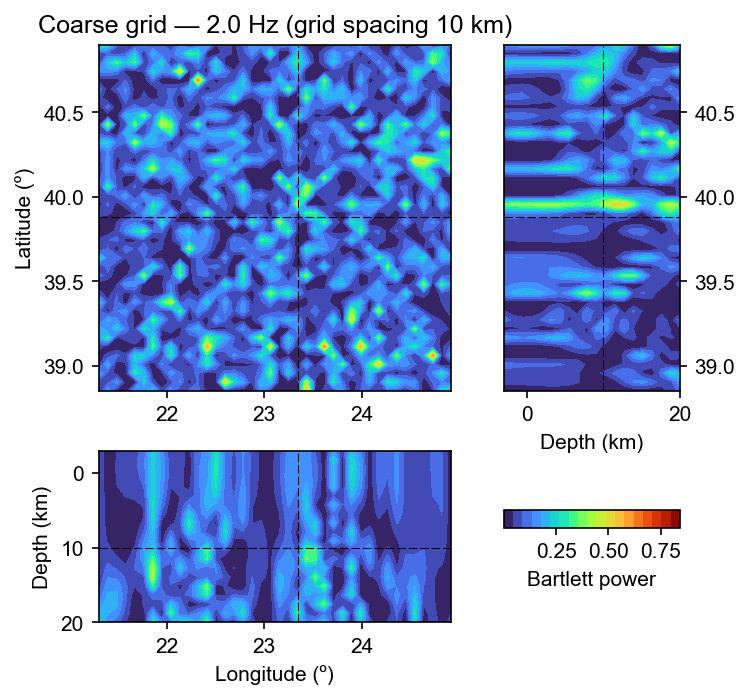

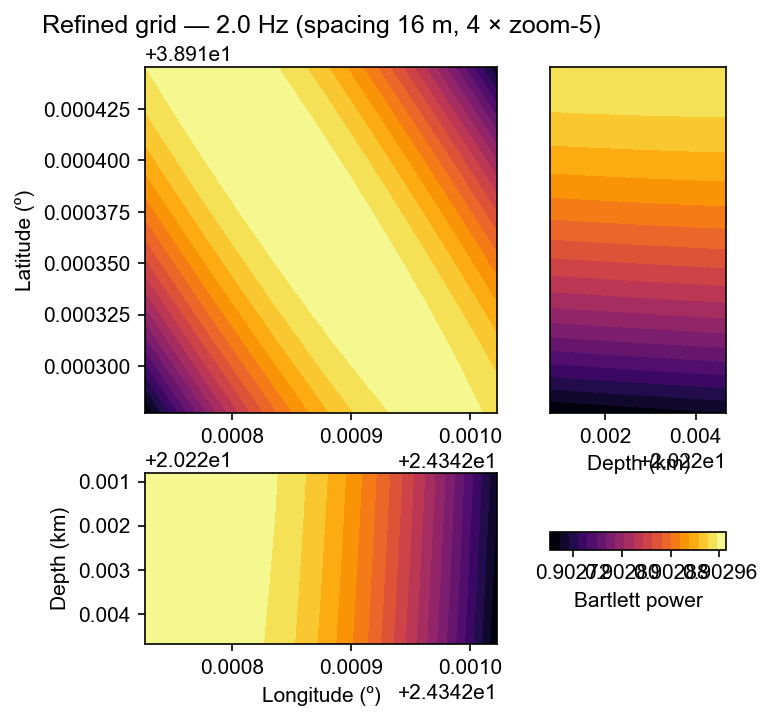

In [200]:
fig, ax = csn.plot.grid3d(
    mfp_coarse,
    profile_coordinates=source,
    cmap="turbo",
    label="Bartlett power",
)
ax["xy"].set_title(
    f"Coarse grid — {frequency:.1f} Hz (grid spacing {grid_spacing_km:.0f} km)"
)

fig, ax = csn.plot.grid3d(
    mfp_fine,
    profile_coordinates=source,
    cmap="inferno",
    label="Bartlett power",
)
ax["xy"].set_title(
    f"Refined grid — {frequency:.1f} Hz "
    f"(spacing {fine_spacing_km*1000:.0f} m, 4 × zoom-5)"
)

## MVDR matched-field processor

The MVDR (minimum-variance distortionless-response) processor typically
achieves higher spatial resolution than Bartlett by suppressing the
sidelobe structure at the cost of a matrix inversion.  We apply it to
the same synthetic covariance and compare the horizontal slice with the
Bartlett result.

MVDR estimate: lon=23.337° lat=39.902° depth=7.9 km


Text(0.5, 1.0, 'Synthetic — MVDR MFP')

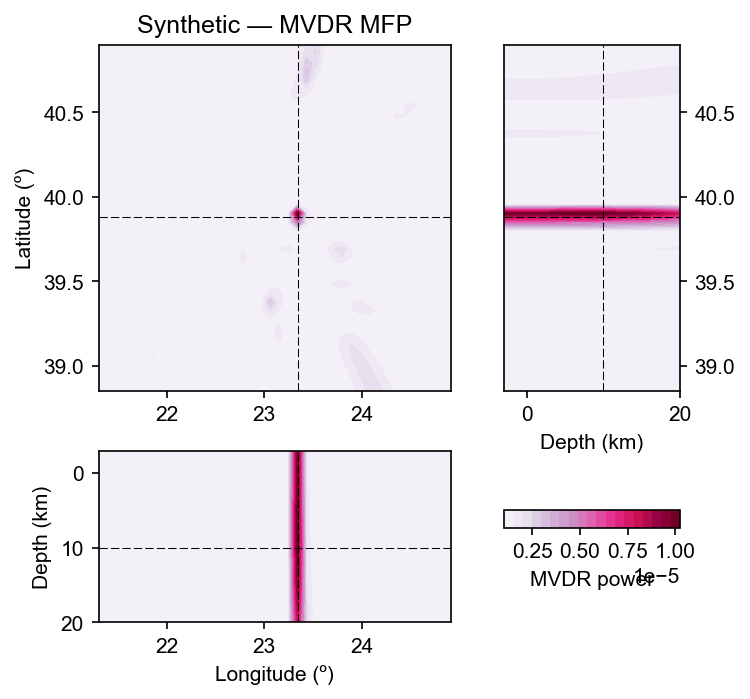

In [120]:
mfp_mvdr = MatchedFieldProcessing(travel_times)
mfp_mvdr.compute_mvdr(cov_hf, frequency)

lon_mv, lat_mv, dep_mv = mfp_mvdr.maximum_coordinates()
print(
    f"MVDR estimate: lon={lon_mv:.3f}° lat={lat_mv:.3f}° depth={dep_mv:.1f} km"
)

fig, ax = csn.plot.grid3d(
    mfp_mvdr,
    profile_coordinates=source,
    # receiver_coordinates=receiver_coords,
    cmap="PuRd",
    label="MVDR power",
)
ax["xy"].set_title("Synthetic — MVDR MFP")

## Application to the real earthquake recording

Two constraints set the usable frequency band:

1. **Spatial sampling**: the Bartlett steering vector $e^{-2\pi i f \tau}$
   oscillates at wavelength $\lambda = v/f$. Correct resolution requires at
   least two grid points per wavelength. With a horizontal grid spacing of
   ~15–20 km, frequencies above ~0.1 Hz are aliased and the power maximum
   lands at an arbitrary grid point.

2. **Incoherent stacking**: at a single frequency the Bartlett map contains
   grating lobes. Averaging the power incoherently over a frequency band
   suppresses them because the lobes shift with frequency while the true
   source maximum stays fixed.

We therefore filter the data to 0.02–0.1 Hz (surface-wave dominated), use a
300 s window to capture all regional arrivals, and stack the Bartlett power
over the band.


In [ ]:
# Work on a copy so accumulated filters don't contaminate the stream
stream_lf = stream.copy()
stream_lf.filter("bandpass", freqmin=0.02, freqmax=0.1)

# 300 s window captures all regional surface-wave arrivals
times, frequencies, covariances = csn.calculate_covariance_matrix(
    stream_lf, window_duration=300, average=1, whiten="none"
)

# Frequency band for incoherent stacking
fmin, fmax = 0.02, 0.1
freq_mask = (frequencies >= fmin) & (frequencies <= fmax)
print(f"Stacking {freq_mask.sum()} frequency bins ({fmin}–{fmax} Hz)")

Using frequency 0.100 Hz


MFP estimate : lon=23.337° lat=39.324° depth=20.0 km
Catalogue    : lon=23.346° lat=39.881° depth=10.0 km


Text(0.5, 1.0, 'Real data — Bartlett MFP at 0.10 Hz')

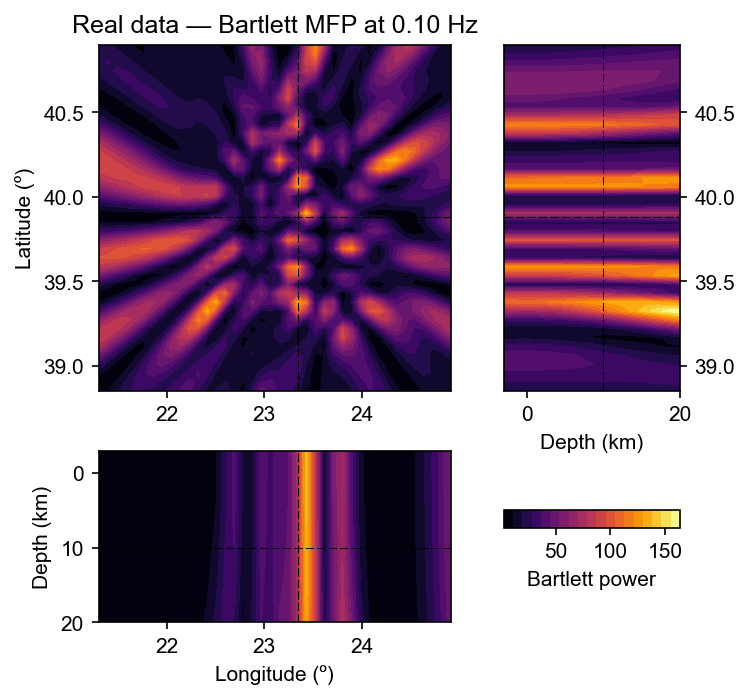

In [ ]:
# Incoherent frequency stacking over the 0.02–0.1 Hz band
power_stack = np.zeros(next(iter(travel_times.values())).shape)
for f, cov_f in zip(frequencies[freq_mask], covariances[0, freq_mask]):
    mfp_f = MatchedFieldProcessing(travel_times)
    mfp_f.compute_bartlett(cov_f, f)
    power_stack += np.nan_to_num(mfp_f)
power_stack /= freq_mask.sum()

# Store in a MatchedFieldProcessing object so grid3d can plot it
mfp_real = MatchedFieldProcessing(travel_times)
mfp_real[...] = power_stack

lon_r, lat_r, dep_r = mfp_real.maximum_coordinates()
print(f"MFP estimate : lon={lon_r:.3f}° lat={lat_r:.3f}° depth={dep_r:.1f} km")
print(
    f"Catalogue    : lon={source[0]:.3f}° lat={source[1]:.3f}° depth={source[2]:.1f} km"
)

fig, ax = csn.plot.grid3d(
    mfp_real,
    profile_coordinates=source_location,
    cmap="inferno",
    label="Bartlett power (0.02–0.1 Hz stack)",
)
ax["xy"].set_title(f"Real data — Bartlett MFP ({fmin}–{fmax} Hz)")